In [1]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv.zip to Sample - Superstore.csv.zip


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

conn = sqlite3.connect('superstore.db')

def run(query):
    return pd.read_sql_query(query, conn)

print('Connected to database.')

Connected to database.


In [4]:
import zipfile
import os

# 1. Unzip the uploaded file
zip_file = 'Sample - Superstore.csv.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

# 2. Find the CSV filename (it might have a slightly different name)
csv_filename = 'Sample - Superstore.csv'

# 3. Load the CSV into the SQLite 'orders' table
df_init = pd.read_csv(csv_filename, encoding='latin1')
df_init.to_sql('orders', conn, if_exists='replace', index=False)

# 4. Now run the query
df = run('SELECT * FROM orders LIMIT 5')
print(f'Columns: {list(df.columns)}')
df

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
run('''
    SELECT
        COUNT(*)                      AS total_rows,
        COUNT(DISTINCT "Customer ID") AS unique_customers,
        COUNT(DISTINCT "Order ID")    AS unique_orders,
        COUNT(DISTINCT "Product ID")  AS unique_products,
        COUNT(DISTINCT "Region")      AS regions,
        COUNT(DISTINCT "Category")    AS categories,
        COUNT(DISTINCT "State")       AS states
    FROM orders
''')

,total_rows,unique_customers,unique_orders,unique_products,regions,categories,states
0,9994,793,5009,1862,4,3,49


In [12]:
# Convert Order Date to datetime and update the table for correct SQL sorting
df_init['Order Date'] = pd.to_datetime(df_init['Order Date'])
df_init.to_sql('orders', conn, if_exists='replace', index=False)

run('''
    SELECT
        MIN("Order Date") AS first_order,
        MAX("Order Date") AS last_order
    FROM orders
''')

,first_order,last_order
0,2014-01-03 00:00:00,2017-12-30 00:00:00


In [9]:
run('''
    SELECT Region,
           COUNT(*)             AS orders,
           ROUND(SUM(Sales), 2) AS total_sales
    FROM orders
    WHERE Region = 'West'
    GROUP BY Region
''')

,Region,orders,total_sales
0,West,3203,725457.82


In [10]:
run('''
    SELECT Category,
           COUNT(*)             AS orders,
           ROUND(SUM(Sales), 2) AS total_sales,
           ROUND(AVG(Sales), 2) AS avg_sale
    FROM orders
    WHERE Category = 'Technology'
    GROUP BY Category
''')

,Category,orders,total_sales,avg_sale
0,Technology,1847,836154.03,452.71


In [13]:
run('''
    SELECT strftime('%Y', "Order Date") AS year,
           COUNT(*)                   AS orders,
           ROUND(SUM(Sales), 2)       AS total_sales
    FROM orders
    WHERE strftime('%Y', "Order Date") = '2017'
    GROUP BY year
''')

,year,orders,total_sales
0,2017,3312,733215.26


In [15]:
run('''
    SELECT "Customer Name",
           "Product Name",
           Sales,
           Profit,
           Region
    FROM orders
    WHERE Sales > 1000
    ORDER BY Sales DESC
    LIMIT 10
''')

,Customer Name,Product Name,Sales,Profit,Region
0,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,South
1,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,17499.950,8399.9760,Central
2,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,13999.960,6719.9808,West
3,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,11199.968,3919.9888,East
4,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,10499.970,5039.9856,East
5,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,4946.3700,Central
6,Sanjit Chand,Ibico EPK-21 Electric Binding System,9449.950,4630.4755,Central
7,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,2365.9818,East
8,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,2799.9840,South
9,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,8399.976,1119.9968,East


In [16]:
run('''
    SELECT COUNT(*)              AS orders,
           ROUND(SUM(Profit), 2) AS total_profit
    FROM orders
    WHERE Discount = 0 AND Profit > 0
''')

,orders,total_profit
0,4768,320987.6


In [17]:
region_df = run('''
    SELECT Region,
           COUNT(*)                  AS orders,
           ROUND(SUM(Sales), 2)      AS total_sales,
           ROUND(SUM(Profit), 2)     AS total_profit,
           ROUND(AVG(Sales), 2)      AS avg_order_value,
           SUM(Quantity)             AS units_sold
    FROM orders
    GROUP BY Region
    ORDER BY total_sales DESC
''')
region_df

,Region,orders,total_sales,total_profit,avg_order_value,units_sold
0,West,3203,725457.82,108418.45,226.49,12266
1,East,2848,678781.24,91522.78,238.34,10618
2,Central,2323,501239.89,39706.36,215.77,8780
3,South,1620,391721.91,46749.43,241.80,6209


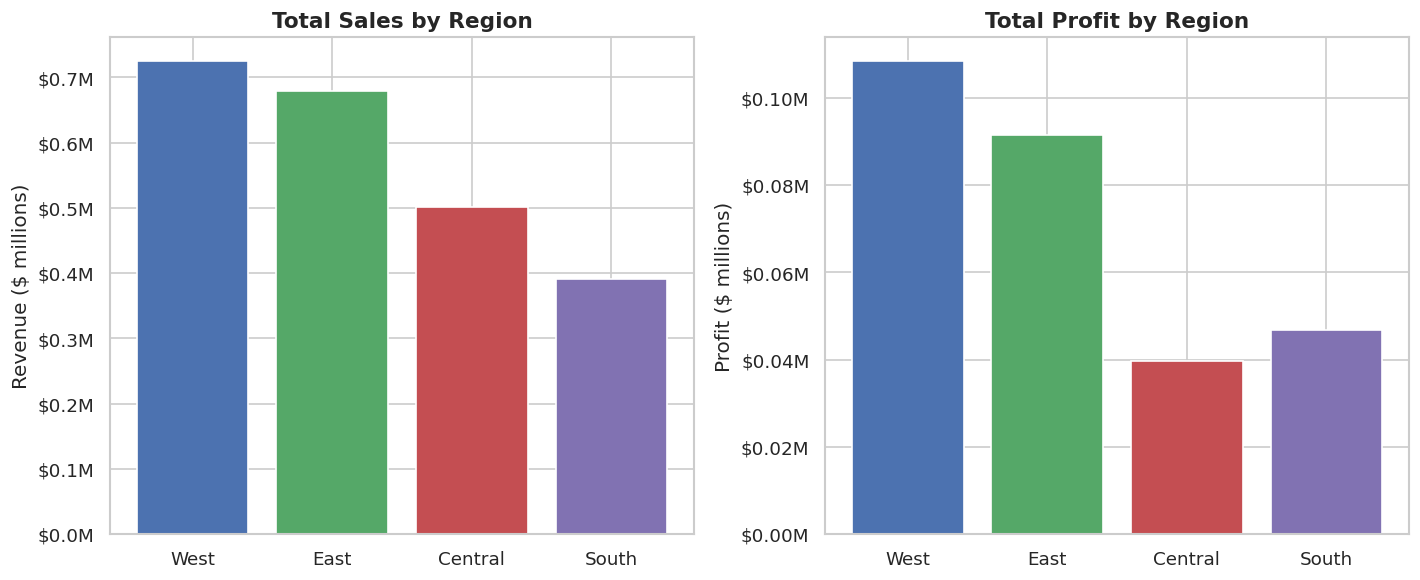

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

axes[0].bar(region_df['Region'], region_df['total_sales'] / 1e6, color=colors, edgecolor='white')
axes[0].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($ millions)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

axes[1].bar(region_df['Region'], region_df['total_profit'] / 1e6, color=colors, edgecolor='white')
axes[1].set_title('Total Profit by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($ millions)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f}M'))

plt.tight_layout()
plt.show()

In [19]:
cat_df = run('''
    SELECT Category,
           COUNT(*)                                  AS orders,
           ROUND(SUM(Sales), 2)                      AS total_sales,
           ROUND(SUM(Profit), 2)                     AS total_profit,
           ROUND(AVG(Discount) * 100, 1)             AS avg_discount_pct,
           ROUND(SUM(Profit) / SUM(Sales) * 100, 2)  AS margin_pct
    FROM orders
    GROUP BY Category
    ORDER BY total_sales DESC
''')
cat_df

,Category,orders,total_sales,total_profit,avg_discount_pct,margin_pct
0,Technology,1847,836154.03,145454.95,13.2,17.40
1,Furniture,2121,741999.80,18451.27,17.4,2.49
2,Office Supplies,6026,719047.03,122490.80,15.7,17.04


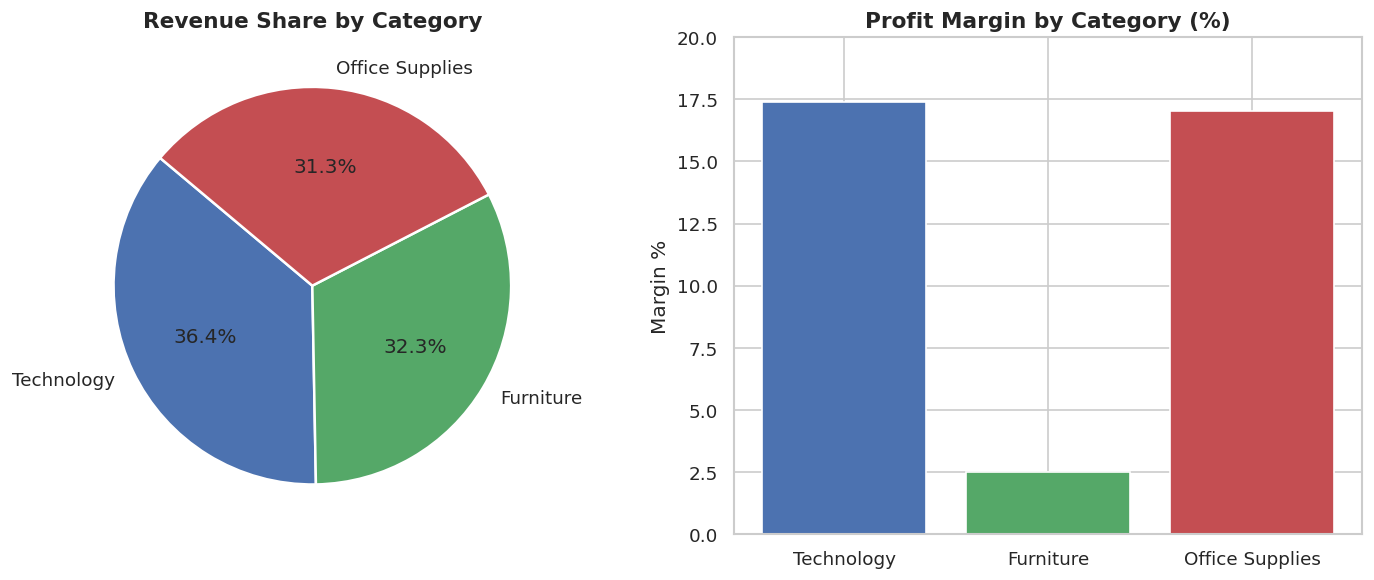

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cat_colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].pie(
    cat_df['total_sales'],
    labels=cat_df['Category'],
    autopct='%1.1f%%',
    colors=cat_colors,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('Revenue Share by Category', fontsize=13, fontweight='bold')

axes[1].bar(cat_df['Category'], cat_df['margin_pct'], color=cat_colors, edgecolor='white')
axes[1].set_title('Profit Margin by Category (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Margin %')
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()


In [22]:
run('''
    SELECT Segment,
           COUNT(*)                      AS orders,
           ROUND(SUM(Sales), 2)          AS total_sales,
           ROUND(SUM(Profit), 2)         AS total_profit,
           COUNT(DISTINCT "Customer ID")   AS unique_customers
    FROM orders
    GROUP BY Segment
    ORDER BY total_sales DESC
''')

,Segment,orders,total_sales,total_profit,unique_customers
0,Consumer,5191,1161401.34,134119.21,409
1,Corporate,3020,706146.37,91979.13,236
2,Home Office,1783,429653.15,60298.68,148


In [24]:
run('''
    SELECT "Ship Mode",
           COUNT(*)                AS orders,
           ROUND(AVG(Sales), 2)    AS avg_sale,
           ROUND(AVG(Quantity), 2) AS avg_quantity,
           ROUND(SUM(Sales), 2)    AS total_sales
    FROM orders
    GROUP BY "Ship Mode"
    ORDER BY total_sales DESC
''')

,Ship Mode,orders,avg_sale,avg_quantity,total_sales
0,Standard Class,5968,227.58,3.82,1358215.74
1,Second Class,1945,236.09,3.82,459193.57
2,First Class,1538,228.50,3.70,351428.42
3,Same Day,543,236.40,3.61,128363.13


In [26]:
top_products = run('''
    SELECT "Product Name",
           Category,
           COUNT(*)               AS times_ordered,
           SUM(Quantity)          AS units_sold,
           ROUND(SUM(Sales), 2)   AS revenue,
           ROUND(SUM(Profit), 2)  AS profit
    FROM orders
    GROUP BY "Product Name", Category
    ORDER BY revenue DESC
    LIMIT 10
''')
top_products

,Product Name,Category,times_ordered,units_sold,revenue,profit
0,Canon imageCLASS 2200 Advanced Copier,Technology,5,20,61599.82,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,10,31,27453.38,7753.04
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,1,6,22638.48,-1811.08
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,8,39,21870.58,0.00
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,11,37,19823.48,2233.51
5,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9,48,19024.50,760.98
6,Hewlett Packard LaserJet 3310 Copier,Technology,8,38,18839.69,6983.88
7,HP Designjet T520 Inkjet Large Format Printer ...,Technology,3,12,18374.90,4094.98
8,GBC DocuBind P400 Electric Binding System,Office Supplies,6,27,17965.07,-1878.17
9,High Speed Automatic Electric Letter Opener,Office Supplies,3,11,17030.31,-262.00


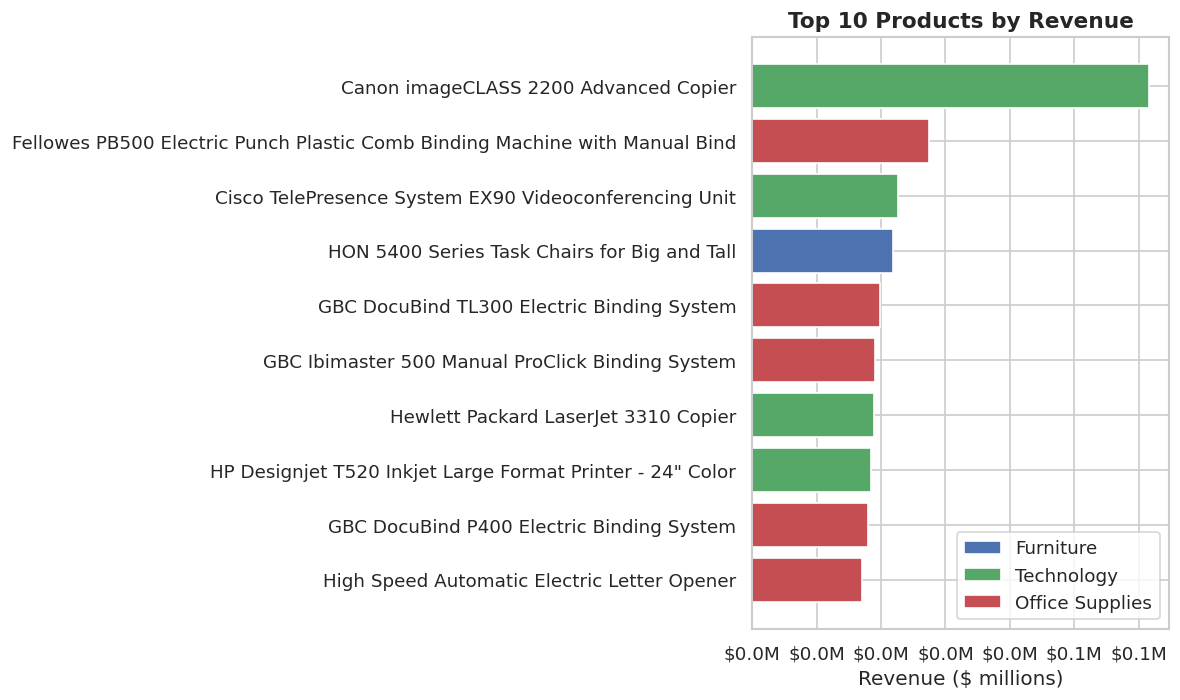

In [28]:
plt.figure(figsize=(10, 6))
colors_map = {'Furniture': '#4C72B0', 'Technology': '#55A868', 'Office Supplies': '#C44E52'}
bar_colors = [colors_map[c] for c in top_products['Category']]

# Fixed: using 'Product Name' instead of 'Product_Name'
plt.barh(top_products['Product Name'][::-1], top_products['revenue'][::-1] / 1e6, color=bar_colors[::-1], edgecolor='white')
plt.xlabel('Revenue ($ millions)')
plt.title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
plt.xaxis = plt.gca().xaxis
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [30]:
run('''
    SELECT "Sub-Category",
           Category,
           COUNT(*)                                  AS orders,
           ROUND(SUM(Sales), 2)                      AS total_sales,
           ROUND(SUM(Profit), 2)                     AS total_profit,
           ROUND(SUM(Profit) / SUM(Sales) * 100, 1)  AS margin_pct
    FROM orders
    GROUP BY "Sub-Category", Category
    ORDER BY total_sales DESC
    LIMIT 10
''')

,Sub-Category,Category,orders,total_sales,total_profit,margin_pct
0,Phones,Technology,889,330007.05,44515.73,13.5
1,Chairs,Furniture,617,328449.10,26590.17,8.1
2,Storage,Office Supplies,846,223843.61,21278.83,9.5
3,Tables,Furniture,319,206965.53,-17725.48,-8.6
4,Binders,Office Supplies,1523,203412.73,30221.76,14.9
5,Machines,Technology,115,189238.63,3384.76,1.8
6,Accessories,Technology,775,167380.32,41936.64,25.1
7,Copiers,Technology,68,149528.03,55617.82,37.2
8,Bookcases,Furniture,228,114880.00,-3472.56,-3.0
9,Appliances,Office Supplies,466,107532.16,18138.01,16.9


In [32]:
top_customers = run('''
    SELECT "Customer Name",
           Segment,
           Region,
           COUNT(DISTINCT "Order ID")  AS orders,
           ROUND(SUM(Sales), 2)      AS lifetime_value,
           ROUND(SUM(Profit), 2)     AS total_profit,
           ROUND(AVG(Sales), 2)      AS avg_order_value
    FROM orders
    GROUP BY "Customer Name", Segment, Region
    ORDER BY lifetime_value DESC
    LIMIT 10
''')
top_customers

,Customer Name,Segment,Region,orders,lifetime_value,total_profit,avg_order_value
0,Sean Miller,Home Office,South,2,23669.20,-1787.04,2958.65
1,Tamara Chand,Corporate,Central,2,18437.14,8745.06,2633.88
2,Raymond Buch,Consumer,West,2,14345.28,6807.09,2390.88
3,Tom Ashbrook,Home Office,East,2,13723.50,4599.21,2744.70
4,Adrian Barton,Consumer,Central,5,12181.59,5362.61,1107.42
5,Becky Martin,Consumer,Central,1,10539.90,-1878.79,1505.70
6,Hunter Lopez,Consumer,East,2,10522.55,5045.86,5261.28
7,Bill Shonely,Corporate,East,2,10022.29,2558.58,2505.57
8,Sanjit Chand,Consumer,Central,1,9900.19,4668.69,2475.05
9,Greg Tran,Consumer,East,5,9382.93,1749.11,852.99


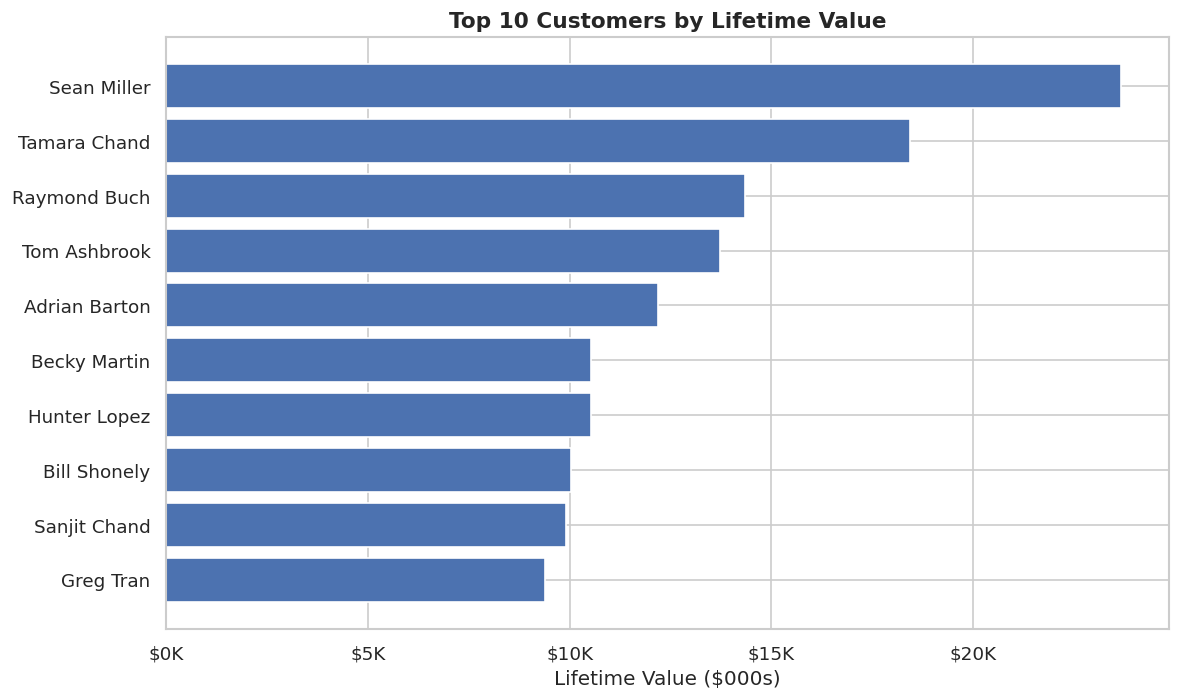

In [34]:
plt.figure(figsize=(10, 6))
plt.barh(top_customers['Customer Name'][::-1], top_customers['lifetime_value'][::-1] / 1e3,
         color='#4C72B0', edgecolor='white')
plt.xlabel('Lifetime Value ($000s)')
plt.title('Top 10 Customers by Lifetime Value', fontsize=13, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
plt.tight_layout()
plt.show()

In [35]:
run('''
    SELECT State,
           Region,
           COUNT(*)               AS orders,
           ROUND(SUM(Sales), 2)   AS total_sales,
           ROUND(SUM(Profit), 2)  AS total_profit
    FROM orders
    GROUP BY State, Region
    ORDER BY total_sales DESC
    LIMIT 10
''')

,State,Region,orders,total_sales,total_profit
0,California,West,2001,457687.63,76381.39
1,New York,East,1128,310876.27,74038.55
2,Texas,Central,985,170188.05,-25729.36
3,Washington,West,506,138641.27,33402.65
4,Pennsylvania,East,587,116511.91,-15559.96
5,Florida,South,383,89473.71,-3399.30
6,Illinois,Central,492,80166.10,-12607.89
7,Ohio,East,469,78258.14,-16971.38
8,Michigan,Central,255,76269.61,24463.19
9,Virginia,South,224,70636.72,18597.95


In [37]:
monthly_df = run('''
    SELECT strftime('%Y-%m', "Order Date") AS month,
           COUNT(*)                      AS orders,
           ROUND(SUM(Sales), 2)          AS monthly_sales,
           ROUND(SUM(Profit), 2)         AS monthly_profit,
           ROUND(AVG(Sales), 2)          AS avg_order_value
    FROM orders
    GROUP BY month
    ORDER BY month
''')
monthly_df.head()

,month,orders,monthly_sales,monthly_profit,avg_order_value
0,2014-01,79,14236.90,2450.19,180.21
1,2014-02,46,4519.89,862.31,98.26
2,2014-03,157,55691.01,498.73,354.72
3,2014-04,135,28295.35,3488.84,209.60
4,2014-05,122,23648.29,2738.71,193.84


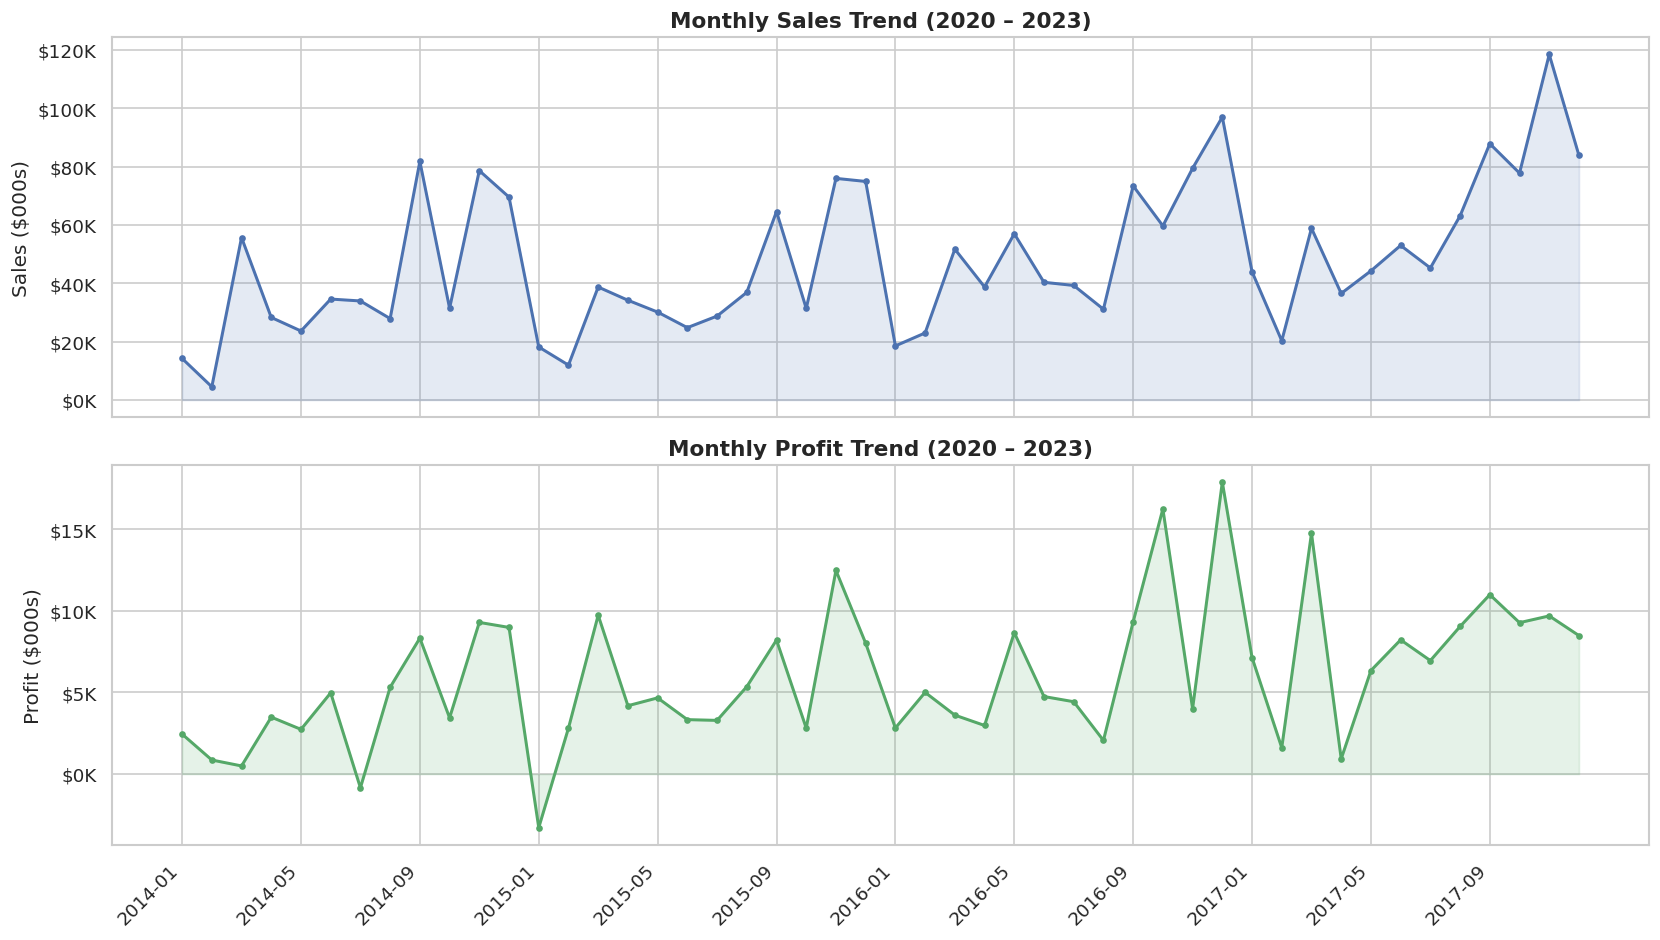

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_df['month'], monthly_df['monthly_sales'] / 1e3,
             color='#4C72B0', linewidth=1.8, marker='o', markersize=3)
axes[0].set_title('Monthly Sales Trend (2020 – 2023)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($000s)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
axes[0].fill_between(monthly_df['month'], monthly_df['monthly_sales'] / 1e3, alpha=0.15, color='#4C72B0')

axes[1].plot(monthly_df['month'], monthly_df['monthly_profit'] / 1e3,
             color='#55A868', linewidth=1.8, marker='o', markersize=3)
axes[1].set_title('Monthly Profit Trend (2020 – 2023)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($000s)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
axes[1].fill_between(monthly_df['month'], monthly_df['monthly_profit'] / 1e3, alpha=0.15, color='#55A868')

tick_positions = list(range(0, len(monthly_df), 4))
tick_labels = [monthly_df['month'].iloc[i] for i in tick_positions]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [40]:
yearly_df = run('''
    SELECT strftime('%Y', "Order Date")  AS year,
           COUNT(*)                    AS orders,
           ROUND(SUM(Sales), 2)        AS annual_sales,
           ROUND(SUM(Profit), 2)       AS annual_profit,
           COUNT(DISTINCT "Customer ID") AS customers
    FROM orders
    GROUP BY year
    ORDER BY year
''')
yearly_df

,year,orders,annual_sales,annual_profit,customers
0,2014,1993,484247.50,49543.97,595
1,2015,2102,470532.51,61618.60,573
2,2016,2587,609205.60,81795.17,638
3,2017,3312,733215.26,93439.27,693


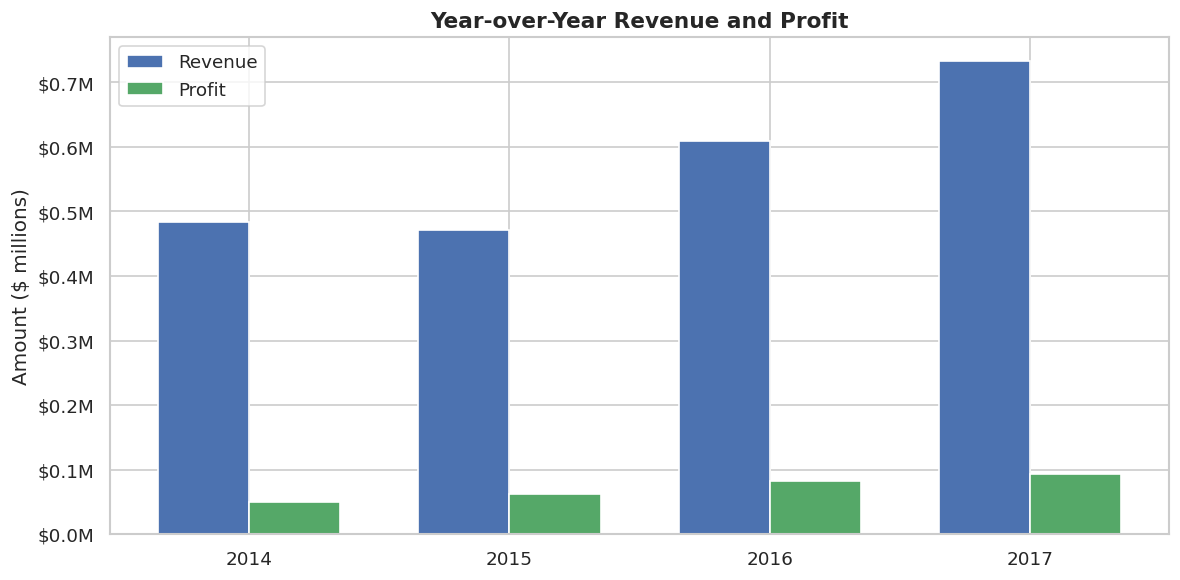

In [41]:
x = range(len(yearly_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], yearly_df['annual_sales'] / 1e6,
       width=width, label='Revenue', color='#4C72B0', edgecolor='white')
ax.bar([i + width/2 for i in x], yearly_df['annual_profit'] / 1e6,
       width=width, label='Profit', color='#55A868', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(yearly_df['year'])
ax.set_ylabel('Amount ($ millions)')
ax.set_title('Year-over-Year Revenue and Profit', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
ax.legend()

plt.tight_layout()
plt.show()

In [42]:
discount_df = run('''
    SELECT
        CASE
            WHEN Discount = 0     THEN 'No discount'
            WHEN Discount <= 0.20 THEN 'Low (1-20%)'
            WHEN Discount <= 0.40 THEN 'Medium (21-40%)'
            ELSE                       'High (>40%)'
        END                       AS discount_tier,
        COUNT(*)                  AS orders,
        ROUND(AVG(Profit), 2)     AS avg_profit,
        ROUND(SUM(Sales), 2)      AS total_sales
    FROM orders
    GROUP BY discount_tier
    ORDER BY avg_profit DESC
''')
discount_df

,discount_tier,orders,avg_profit,total_sales
0,No discount,4798,66.90,1087908.47
1,Low (1-20%),3803,26.50,846522.24
2,Medium (21-40%),460,-77.86,234137.90
3,High (>40%),933,-106.71,128632.25


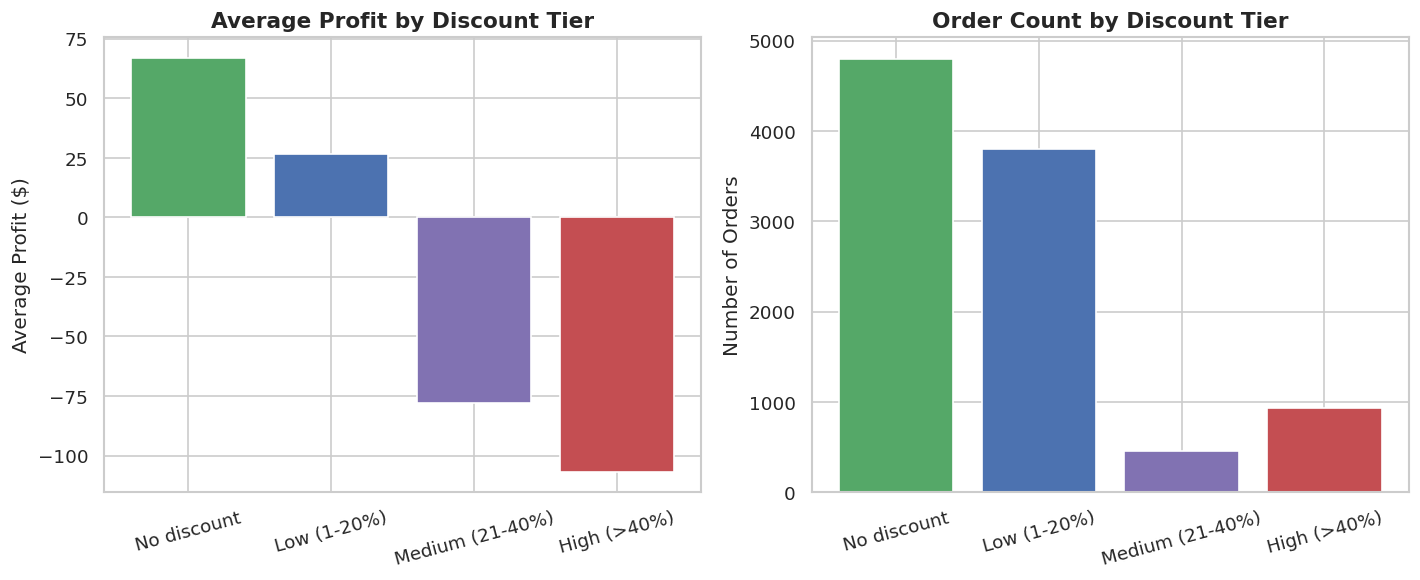

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tier_order = ['No discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (>40%)']
discount_df['discount_tier'] = pd.Categorical(discount_df['discount_tier'], categories=tier_order, ordered=True)
discount_df = discount_df.sort_values('discount_tier')

tier_colors = ['#55A868', '#4C72B0', '#8172B2', '#C44E52']

axes[0].bar(discount_df['discount_tier'], discount_df['avg_profit'],
            color=tier_colors, edgecolor='white')
axes[0].set_title('Average Profit by Discount Tier', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Profit ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(discount_df['discount_tier'], discount_df['orders'],
            color=tier_colors, edgecolor='white')
axes[1].set_title('Order Count by Discount Tier', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [45]:
run('''
    SELECT
        SUM(CASE WHEN "Customer ID" IS NULL THEN 1 ELSE 0 END) AS null_customer_id,
        SUM(CASE WHEN Sales         IS NULL THEN 1 ELSE 0 END) AS null_sales,
        SUM(CASE WHEN "Order Date"   IS NULL THEN 1 ELSE 0 END) AS null_order_date,
        SUM(CASE WHEN Region        IS NULL THEN 1 ELSE 0 END) AS null_region,
        SUM(CASE WHEN Category      IS NULL THEN 1 ELSE 0 END) AS null_category
    FROM orders
''')

,null_customer_id,null_sales,null_order_date,null_region,null_category
0,0,0,0,0,0


In [47]:
dupes = run('''
    SELECT "Order ID", "Customer ID", "Product ID", COUNT(*) AS occurrences
    FROM orders
    GROUP BY "Order ID", "Customer ID", "Product ID"
    HAVING COUNT(*) > 1
    ORDER BY occurrences DESC
    LIMIT 5
''')
print(f'Duplicate rows found: {len(dupes)}')
dupes

Duplicate rows found: 5


,Order ID,Customer ID,Product ID,occurrences
0,CA-2015-103135,SS-20515,OFF-BI-10000069,2
1,CA-2016-129714,AB-10060,OFF-PA-10001970,2
2,CA-2016-137043,LC-17140,FUR-FU-10003664,2
3,CA-2016-140571,SJ-20125,OFF-PA-10001954,2
4,CA-2017-118017,LC-16870,TEC-AC-10002006,2


In [48]:
run('''
    SELECT COUNT(*)                                                    AS loss_making_orders,
           ROUND(SUM(Profit), 2)                                       AS total_loss,
           ROUND(AVG(Discount) * 100, 1)                               AS avg_discount_pct,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 1)  AS pct_of_all_orders
    FROM orders
    WHERE Profit < 0
''')

,loss_making_orders,total_loss,avg_discount_pct,pct_of_all_orders
0,1871,-156131.29,48.1,18.7


In [49]:
run('''
    SELECT
        ROUND(MIN(Sales),  2) AS min_sale,
        ROUND(MAX(Sales),  2) AS max_sale,
        ROUND(AVG(Sales),  2) AS avg_sale,
        ROUND(MIN(Profit), 2) AS min_profit,
        ROUND(MAX(Profit), 2) AS max_profit,
        ROUND(AVG(Profit), 2) AS avg_profit
    FROM orders
''')

,min_sale,max_sale,avg_sale,min_profit,max_profit,avg_profit
0,0.44,22638.48,229.86,-6599.98,8399.98,28.66


In [50]:
conn.close()